In [1]:
# Instalar LightGBM directamente desde el notebook
!pip install lightgbm optuna

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# 1. Carga de datos
input_path = '../data/Filtered.pkl' # Asegúrate de haber guardado el df_filtered del notebook anterior con este nombre

print("📥 Cargando dataset para modelado...")
if os.path.exists(input_path):
    df = pd.read_pickle(input_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print(f"❌ Error: No se encontró el archivo en {input_path}")

# Vista rápida
display(df.head(3))

📥 Cargando dataset para modelado...
✅ Dataset cargado correctamente: 114567 filas y 15 columnas.


,order_id,is_delayed,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


In [2]:
# 1. Selección de variables y limpieza de identificadores
# Eliminamos 'order_id' (no predictivo) y el target. 
# Añadimos errors='ignore' para que no falle si las columnas de lat/lng no existen en este paso.
features_to_drop = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']
X = df.drop(columns=features_to_drop + ['is_delayed'], errors='ignore')
y = df['is_delayed']

# 2. Definición de variables categóricas
# LightGBM funciona mejor si le indicamos explícitamente cuáles son categorías
cat_cols = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"✅ Codificación completada. Variables predictoras: {X.shape[1]}")
print(f"Columnas categóricas detectadas: {cat_cols}")

✅ Codificación completada. Variables predictoras: 13
Columnas categóricas detectadas: ['product_category_name_english', 'customer_state_num_pred', 'seller_state_num_pred', 'purchase_month', 'purchase_day_of_week', 'is_same_state']


In [3]:
# Cálculo del balance de clases
num_neg = (y == 0).sum()
num_pos = (y == 1).sum()

# El peso ideal es la proporción de negativos sobre positivos
scale_pos_weight = num_neg / num_pos

print(f"📊 Análisis de Balance:")
print(f" - Pedidos a tiempo (0): {num_neg}")
print(f" - Pedidos retrasados (1): {num_pos}")
print(f" - Factor 'scale_pos_weight' recomendado: {scale_pos_weight:.2f}")
print("\nEste valor se pasará como parámetro al modelo para compensar el desequilibrio.")

📊 Análisis de Balance:
 - Pedidos a tiempo (0): 105642
 - Pedidos retrasados (1): 8925
 - Factor 'scale_pos_weight' recomendado: 11.84

Este valor se pasará como parámetro al modelo para compensar el desequilibrio.


In [4]:
from sklearn.model_selection import train_test_split

# 1. Primero separamos un 15% para el Test final (datos nunca vistos)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# 2. Del 85% restante, separamos otro 15% para Verificación/Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, stratify=y_train_val, random_state=42
)

print("📈 División de datos finalizada (72% / 13% / 15%):")
print(f" - Entrenamiento (Train): {X_train.shape[0]} registros")
print(f" - Validación (Val): {X_val.shape[0]} registros")
print(f" - Prueba (Test): {X_test.shape[0]} registros")

📈 División de datos finalizada (72% / 13% / 15%):
 - Entrenamiento (Train): 82773 registros
 - Validación (Val): 14608 registros
 - Prueba (Test): 17186 registros


In [6]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score

def objective(trial):
    # 1. Definir el espacio de búsqueda
    param = {
        'objective': 'binary',
        'metric': 'auc',             # ✅ Volvemos a 'auc' para que el Early Stopping funcione
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': 1000,
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight)
    }

    gbm = lgb.LGBMClassifier(**param)
    
    # 2. Entrenamiento
    gbm.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=cat_cols,
        callbacks=[
            # Vigilamos el AUC para detenernos, pero Optuna optimizará el F1 final
            lgb.early_stopping(stopping_rounds=50, first_metric_only=True, verbose=False)
        ]
    )

    # 3. Cálculo de la métrica que realmente nos importa (F1)
    preds = gbm.predict(X_val) 
    f1 = f1_score(y_val, preds)
    
    return f1

# 3. Ejecución del estudio
print("🕵️‍♂️ Iniciando Optimización Bayesiana para maximizar F1-Score...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n🏆 OPTIMIZACIÓN FINALIZADA")
print(f"Mejor F1-Score detectado: {study.best_value:.4f}")
print("Mejores parámetros:", study.best_params)

[I 2026-04-09 13:32:04,811] A new study created in memory with name: no-name-4010c654-52e2-409b-9954-689266573230


🕵️‍♂️ Iniciando Optimización Bayesiana para maximizar F1-Score...


[I 2026-04-09 13:32:07,821] Trial 0 finished with value: 0.39044709802832545 and parameters: {'learning_rate': 0.070419026857329, 'num_leaves': 82, 'max_depth': 6, 'min_child_samples': 93, 'subsample': 0.8711768838545151, 'colsample_bytree': 0.7656407746442024, 'scale_pos_weight': 9.725685072782621}. Best is trial 0 with value: 0.39044709802832545.
[I 2026-04-09 13:32:11,213] Trial 1 finished with value: 0.400599700149925 and parameters: {'learning_rate': 0.06314156501570206, 'num_leaves': 111, 'max_depth': 6, 'min_child_samples': 24, 'subsample': 0.7643932104908912, 'colsample_bytree': 0.9678341709548096, 'scale_pos_weight': 8.680593834874989}. Best is trial 1 with value: 0.400599700149925.
[I 2026-04-09 13:32:14,542] Trial 2 finished with value: 0.3902439024390244 and parameters: {'learning_rate': 0.09209182794730121, 'num_leaves': 73, 'max_depth': 12, 'min_child_samples': 31, 'subsample': 0.6791346006834575, 'colsample_bytree': 0.9641014964779991, 'scale_pos_weight': 2.4854766255696


🏆 OPTIMIZACIÓN FINALIZADA
Mejor F1-Score detectado: 0.4565
Mejores parámetros: {'learning_rate': 0.049882597043809804, 'num_leaves': 143, 'max_depth': 11, 'min_child_samples': 72, 'subsample': 0.8091074190865053, 'colsample_bytree': 0.6391241311042988, 'scale_pos_weight': 4.225895521476627}


In [7]:
# Recuperar los mejores parámetros
best_params = study.best_params
# Añadir los parámetros fijos que no variamos
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['n_estimators'] = 2000 # Le damos más cuerda para el modelo final

# Entrenar modelo final
model_lgb_final = lgb.LGBMClassifier(**best_params)
model_lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(stopping_rounds=100, first_metric_only=True)]
)

print("✅ Modelo final optimizado listo para evaluación.")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[368]	valid_0's auc: 0.83953
Evaluated only: auc
✅ Modelo final optimizado listo para evaluación.


💾 1. GUARDANDO EL MODELO...
✅ Modelo guardado exitosamente en: ../models/lgbm_logistics_model.pkl

🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...
----------------------------------------
🔹 Accuracy (Exactitud):  0.9184 (Recuerda: puede ser engañosa)
🔹 Precision (Precisión): 0.4749 (De los que predijo retraso, % que realmente lo fue)
🔹 Recall (Sensibilidad): 0.4444 (De TODOS los retrasos reales, % que logró detectar)
🔹 F1-Score:              0.4591 (El equilibrio entre Precisión y Recall)
🔹 ROC-AUC:               0.8364 (Capacidad general de separar las dos clases)
----------------------------------------

📋 REPORTE DE CLASIFICACIÓN DETALLADO:
               precision    recall  f1-score   support

 A Tiempo (0)       0.95      0.96      0.96     15847
Retrasado (1)       0.47      0.44      0.46      1339

     accuracy                           0.92     17186
    macro avg       0.71      0.70      0.71     17186
 weighted avg       0.92      0.92      0.92     17186



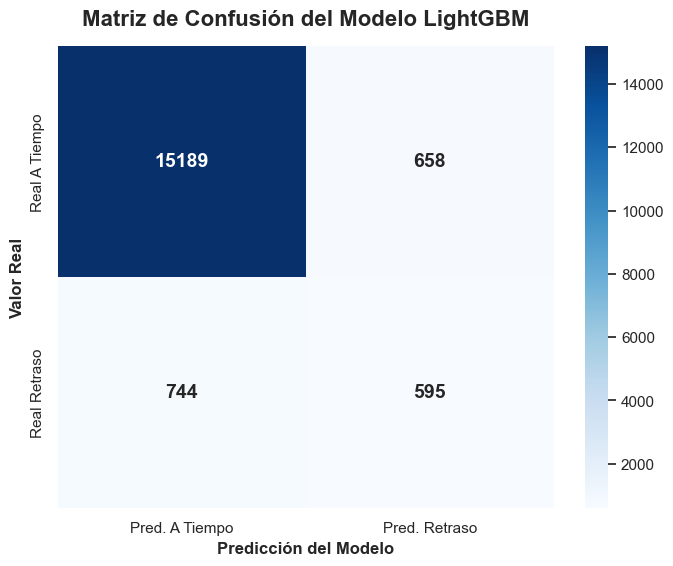

In [8]:
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

print("💾 1. GUARDANDO EL MODELO...")
# Crear el directorio si no existe
os.makedirs('../models', exist_ok=True)
model_path = '../models/lgbm_logistics_model.pkl'

# Guardar el modelo usando joblib
joblib.dump(model_lgb_final, model_path)
print(f"✅ Modelo guardado exitosamente en: {model_path}\n")

print("🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...")
# Generar predicciones (0 o 1) y probabilidades (0.0 a 1.0)
y_pred = model_lgb_final.predict(X_test)
y_prob = model_lgb_final.predict_proba(X_test)[:, 1] # Probabilidad de pertenecer a la clase 1 (Retraso)

# Calcular métricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Imprimir el resumen ejecutivo
print("-" * 40)
print(f"🔹 Accuracy (Exactitud):  {acc:.4f} (Recuerda: puede ser engañosa)")
print(f"🔹 Precision (Precisión): {prec:.4f} (De los que predijo retraso, % que realmente lo fue)")
print(f"🔹 Recall (Sensibilidad): {rec:.4f} (De TODOS los retrasos reales, % que logró detectar)")
print(f"🔹 F1-Score:              {f1:.4f} (El equilibrio entre Precisión y Recall)")
print(f"🔹 ROC-AUC:               {auc:.4f} (Capacidad general de separar las dos clases)")
print("-" * 40)

print("\n📋 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_test, y_pred, target_names=['A Tiempo (0)', 'Retrasado (1)']))

# 3. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Crear el heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred. A Tiempo', 'Pred. Retraso'], 
            yticklabels=['Real A Tiempo', 'Real Retraso'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Matriz de Confusión del Modelo LightGBM', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.show()